# Evaluating the emulator

This short notebook wil compare the emulator from earlier in part 2 to our model we trained in python in part 1

In [1]:
import os, shutil, json

#Third parties
import numpy as np
import tensorflow as tf
from qkeras.utils import load_qmodel
from sklearn.metrics import roc_curve, auc,precision_recall_curve
import hls4ml

#Plotting
import matplotlib.pyplot as plt

# from utils.data import make_data,load_data,to_ML
# from utils.plotting import plot_histo, plot_2d

2026-06-18 21:42:56.872515: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-18 21:42:57.144562: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-18 21:42:57.490454: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-18 21:42:57.490584: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-18 21:42:57.490660: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

WARN: Unable to import optimizer(s) from expr_templates.py: No module named 'sympy'


/home/antsruin/L1_Trigger/tagger_env/lib/python3.11/site-packages/hls4ml/converters/__init__.py:29: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


In [2]:
def rms(array):
   return np.sqrt(np.mean(array ** 2))


# Load Model

Load our model from part 1, this can be changed to point at your model

In [3]:

model = load_qmodel('./output2/gnn_tagger_v2/model/saved_model.h5')


2026-06-18 21:43:30.053214: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-18 21:43:30.054593: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
model_baseline = load_qmodel('./Analysis/baseline.h5')

In [5]:
print("hls4ml layer names:")
for layer in model.layers:
    print(f"  {layer.name}: {layer.name}")

hls4ml layer names:
  model_input: model_input
  bn_input: bn_input
  adj_input: adj_input
  gcn_dense_0: gcn_dense_0
  gcn_agg_0: gcn_agg_0
  gcn_act_0: gcn_act_0
  gcn_dense_1: gcn_dense_1
  gcn_agg_1: gcn_agg_1
  gcn_act_1: gcn_act_1
  act_pool: act_pool
  pool: pool
  dense_0: dense_0
  act_0: act_0
  dense_1: dense_1
  act_1: act_1
  jet_pt_regression_dense: jet_pt_regression_dense
  jet_id_classification: jet_id_classification
  jet_pt_regression_act: jet_pt_regression_act
  jet_id_output: jet_id_output
  pT_output: pT_output


# Load Data

Load our data from the emulator in part 2, by default it will create a file ```jetTuple_extended_5.root``` in ```CMSSW_15_1_0_pre1/src/FastPUPPI/NtupleMaker/python```

In [6]:
import uproot
with uproot.open('./Analysis/jetTuple_extended_5.root') as f:
    # Check what tree is available
    print(f.keys())
    tree = f['outnano/Jets']   # typical JetNTuplizer tree path — adjust if different
    
    # Load the SC4NG scores from CMSSW emulation
    cmssw_branches = tree.keys()
    print(cmssw_branches)   # find exact branch names first

['outnano;1', 'outnano/Jets;1']
['event', 'ngenH', 'genH_pt', 'genH_mass', 'genHH_pt', 'genHH_mass', 'jet_eta', 'jet_eta_phys', 'jet_phi', 'jet_phi_phys', 'jet_pt', 'jet_pt_phys', 'jet_pt_raw', 'jet_mass', 'jet_energy', 'jet_SC4NGJet_score_b', 'jet_SC4NGJet_score_light', 'jet_SC4NGJet_score_gluon', 'jet_SC4NGJet_score_charm', 'jet_SC4NGJet_score_taup', 'jet_SC4NGJet_score_taum', 'jet_SC4NGJet_score_muon', 'jet_SC4NGJet_score_electron', 'jet_SC4NGJet_score_regression', 'jet_bjetscore', 'jet_tauscore', 'jet_eletkiso', 'jet_elepfiso', 'jet_elepuppiiso', 'jet_muoniso', 'jet_taupt', 'jet_taueta', 'jet_reject', 'jet_tauflav', 'jet_muflav', 'jet_elflav', 'jet_taudecaymode', 'jet_lepflav', 'jet_taucharge', 'jet_genmatch_lep_pt', 'jet_genmatch_lep_vis_pt', 'jet_genmatch_lep_dR', 'jet_genmatch_pt', 'jet_genmatch_eta', 'jet_genmatch_phi', 'jet_genmatch_mass', 'jet_genmatch_dR', 'jet_taumatch_dR', 'jet_elematch_dR', 'jet_muonmatch_dR', 'jet_genmatch_hflav', 'jet_genmatch_pflav', 'jet_jecmatch_dR',

In [7]:
!source ./setup.sh

In [186]:
# !python /home/antsruin/L1_Trigger/TrainTagger/tagger/data/make_data.py -i ./Analysis/jetTuple_extended_5.root 

In [8]:
!pwd

/home/antsruin/L1_Trigger/TrainTagger


In [9]:
from tagger.data.tools import make_data
from tagger.data.tools import load_data, to_ML

In [189]:
# make_data(infile='./Analysis/jetTuple_extended_5.root', outdir="./Analysis/emulation_data_1/", extras='extra_emulation_fields', tree="outnano/Jets")

In [10]:
(X_train, ADJ_train, y_train_raw,  pt_train,  reco_pt_train,
    X_test,  ADJ_test,  y_test_raw,   pt_test,   reco_pt_test,
    class_labels, input_vars, extra_vars) = load_data(
    './Analysis/emulation_data_1/',
    percentage=100,
    test_ratio=0.0,
    build_graph=True,
    knn=5
)
# X_test, Y_test, pt_target, truth_pt, _ = to_ML(data, class_labels) #Last thing was reconstructed pt
labels = list(class_labels.keys())

Loading data from:  ./Analysis/emulation_data_1/
Loading percentage:  100
With test ratio of:  0.0
Building KNN graphs (k=5)...
  Building train graphs...


  Building test graphs...
X_train shape  : (1175, 16, 20)
ADJ_train shape: (1175, 16, 16)
X_test shape   : (0, 16, 20)


In [11]:
data, _, class_labels, input_vars, extra_vars = load_data('./Analysis/emulation_data_1/', percentage=100,test_ratio=0.0)
X_test, Y_test, pt_target, truth_pt, _ = to_ML(data, class_labels) #Last thing was reconstructed pt
labels = list(class_labels.keys())
print(X_test.shape)

Loading data from:  ./Analysis/emulation_data_1/
Loading percentage:  100
With test ratio of:  0.0
(1175, 16, 20)


In [ ]:

print(len(pt_train), len(pt_target))
print(np.allclose(pt_train, pt_target, atol=1e-6))
print(np.max(np.abs(pt_train - pt_target)))

1175 1175
False
1.6920035


In [12]:
print("Class labels:", labels)

Class labels: ['b', 'charm', 'light', 'gluon', 'taup', 'taum', 'muon', 'electron']


# Convert the model

This function runs the conversion to hls, to match the emulator this conversion needs to be the same as part 1 with the correct precisions

In [13]:

def convert(model ,outdir = './Analysis/' ):
    input_precision = 'ap_fixed<24,12,AP_RND,AP_SAT>'
    class_precision = 'ap_ufixed<24,12,AP_RND,AP_SAT>'
    reg_precision = 'ap_fixed<16,6,AP_RND,AP_SAT>' 
    trace=True

    #Create default config
    config = hls4ml.utils.config_from_keras_model(model, granularity='name')
    config['IOType'] = 'io_parallel'
    # config['LayerName']['model_input']['Precision']['result'] = input_precision

    # #Configuration for conv1d layers
    # #hls4ml automatically figures out the paralellization factor
    # config['LayerName']['Conv1D_1']['ParallelizationFactor'] = 8
    # config['LayerName']['Conv1D_2']['ParallelizationFactor'] = 8

     #Additional config
    for layer in model.layers:
        layer_name  = layer.name
        layer_class = layer.__class__.__name__

        if layer_class in ['InputLayer']:
            config['LayerName'][layer_name]['Precision']['result'] = \
                input_precision

        elif layer_class in ['QBatchNormalization', 'BatchNormalization']:
            config['LayerName'][layer_name]['Precision'] = \
                input_precision
            config['LayerName'][layer_name]['result'] = \
                input_precision
            config['LayerName'][layer_name]['Trace'] = trace

        elif layer_class == 'Dot':
            # Adjacency matmul — keep same precision as input
            config['LayerName'][layer_name]['Precision'] = \
                input_precision
            config['LayerName'][layer_name]['Trace'] = trace

        elif layer_class in ['Permute', 'Reshape', 'Flatten', 'Concatenate']:
            # Reshape ops — no weights, skip trace
            print(f'Skipping trace for: {layer_name}')

        else:
            config['LayerName'][layer_name]['Trace'] = trace

        
    config["LayerName"]["jet_id_output"]["Precision"]["result"] = class_precision
    config["LayerName"]["jet_id_output"]["Implementation"] = "latency"
    config["LayerName"]["pT_output"]["Precision"]["result"] = reg_precision
    config["LayerName"]["pT_output"]["Implementation"] = "latency"


    #Write HLS
    hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                        backend='Vitis',
                                                        project_name='L1',
                                                        clock_period=2.8, #1/360MHz = 2.8ns
                                                        hls_config=config,
                                                        output_dir='L1TGNNJetModel_V1',
                                                        part='xcvu9p-flga2104-2L-e')

    hls_model.compile()
    return hls_model


In [14]:
def convert_baseline(model ,outdir = 'fw_model_1' ):
    input_precision = 'ap_fixed<24,12,AP_RND,AP_SAT>'
    class_precision = 'ap_ufixed<24,12,AP_RND,AP_SAT>'
    reg_precision = 'ap_fixed<16,6,AP_RND,AP_SAT>' 
    trace=True

    #Create default config
    config = hls4ml.utils.config_from_keras_model(model, granularity='name')
    config['IOType'] = 'io_parallel'
    config['LayerName']['model_input']['Precision']['result'] = input_precision

    #Configuration for conv1d layers
    #hls4ml automatically figures out the paralellization factor
    config['LayerName']['Conv1D_1']['ParallelizationFactor'] = 8
    config['LayerName']['Conv1D_2']['ParallelizationFactor'] = 8

     #Additional config
    for layer in model.layers:
        layer_name = layer.__class__.__name__

        if layer_name in ["BatchNormalization", "InputLayer"]:
            config["LayerName"][layer.name]["Precision"] = input_precision
            config["LayerName"][layer.name]["result"] = input_precision
            config["LayerName"][layer.name]["Trace"] = trace
        elif layer_name in ["Permute","Concatenate","Flatten","Reshape","UpSampling1D","Add"]:
            print("Skipping trace for:", layer.name)
        else:
            config["LayerName"][layer.name]["Trace"] = trace

        
    config["LayerName"]["jet_id_output"]["Precision"]["result"] = class_precision
    config["LayerName"]["jet_id_output"]["Implementation"] = "latency"
    config["LayerName"]["pT_output"]["Precision"]["result"] = reg_precision
    config["LayerName"]["pT_output"]["Implementation"] = "latency"


    #Write HLS
    hls_model = hls4ml.converters.convert_from_keras_model(model,
                                                        backend='Vitis',
                                                        project_name='model_emu_v1',
                                                        clock_period=2.8, #1/360MHz = 2.8ns
                                                        hls_config=config,
                                                        output_dir='fw_model_1',
                                                        part='xcvu9p-flga2104-2L-e')

    hls_model.compile()
    return hls_model

In [15]:

hls_model = convert(model)
hls_model_baseline = convert_baseline(model_baseline)

/home/antsruin/L1_Trigger/tagger_env/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Interpreting Model
Topology:
Layer name: model_input, layer type: InputLayer, input shapes: [[None, 16, 20]], output shape: [None, 16, 20]
Layer name: bn_input, layer type: BatchNormalization, input shapes: [[None, 16, 20]], output shape: [None, 16, 20]
Layer name: adj_input, layer type: InputLayer, input shapes: [[None, 16, 16]], output shape: [None, 16, 16]
Layer name: gcn_dense_0, layer type: QDense, input shapes: [[None, 16, 20]], output shape: [None, 16, 32]
Layer name: gcn_agg_0, layer type: Dot, input shapes: [[None, 16, 16], [None, 16, 32]], output shape: [None, 16, 32]
Layer name: gcn_act_0, layer type: Activation, input shapes: [[None, 16, 32]], output shape: [None, 16, 32]
Layer name: gcn_dense_1, layer type: QDense, input shapes: [[None, 16, 32]], output shape: [None, 16, 32]
Layer name: gcn_agg_1, layer type: Dot, input shapes: [[None, 16, 16], [None, 16, 32]], output shape: [None, 16, 32]
Layer name: gcn_act_1, layer type: Activation, input shapes: [[None, 16, 32]], outpu

# Predicitions

Run predictions with the model, hls4ml models need their inputs as contiguous arrays

In [16]:
y_hls, y_ptreg_hls = hls_model.predict([np.ascontiguousarray(X_train),
        np.ascontiguousarray(ADJ_train)])
y_class, y_ptreg = model.predict([np.ascontiguousarray(X_train),
        np.ascontiguousarray(ADJ_train)])


37/37 [==============================] - 4s 20ms/step


In [37]:
print(y_hls.shape)

(1175, 8)


In [38]:
print("hls_model output shape:", y_ptreg_hls.shape)

hls_model output shape: (1175, 1)


In [17]:
y_hls_baseline, y_ptreg_hls_baseline = hls_model_baseline.predict(np.ascontiguousarray(X_test))
y_class_baseline, y_ptreg_baseline = model_baseline.predict(np.ascontiguousarray(X_test))

37/37 [==============================] - 5s 29ms/step


In [43]:
LINESTYLES = ["-","--","dotted","-","dotted","-","-",(0, (3, 5, 1, 5)),(0, (3, 5, 1,1,1,5,)),(0, (3, 10, 1, 10)),(0, (3, 10, 1, 10, 1, 10))]

def plot_2d(variable_one,variable_two,range_one,range_two,name_one,name_two,title):
    fig,ax = plt.subplots(1,1,figsize=(12,10))
    
    hist2d = ax.hist2d(variable_one, variable_two, range=(range_one,range_two), bins=50,cmap='jet')
    ax.set_xlabel(name_one)
    ax.set_ylabel(name_two)
    cbar = plt.colorbar(hist2d[3] , ax=ax)
    cbar.set_label('a.u.')
    plt.suptitle(title)
    return fig

# def plot_histo(variable,name,title,xlabel,ylabel,range=(0,1)):
#     plt.clf()
#     fig,ax = plt.subplots(1,1,figsize=(12,10))
#     for i,histo in enumerate(variable):

#         ax.hist(histo,bins=50,range=range,histtype="step",
#                     label=name[i],
#                     linewidth = 2,
#                     linestyle = LINESTYLES[i],
#                     density=True)    
#     ax.grid(True)
#     ax.set_xlabel(xlabel,ha="right",x=1)
#     ax.set_ylabel(ylabel,ha="right",y=1)
#     ax.legend(loc='upper right')
#     return fig
def plot_histo(variable, name, title, xlabel, ylabel, range=(0,1), colors=None):
    plt.clf()
    fig, ax = plt.subplots(1, 1, figsize=(12,10))
    for i, histo in enumerate(variable):
        kwargs = dict(
            bins=50, range=range, histtype="step",
            label=name[i], linewidth=2,
            linestyle=LINESTYLES[i], density=True
        )
        if colors is not None:
            kwargs["color"] = colors[i]
        ax.hist(histo, **kwargs)
    ax.grid(True)
    ax.set_xlabel(xlabel, ha="right", x=1)
    ax.set_ylabel(ylabel, ha="right", y=1)
    ax.legend(loc='upper right')
    return fig


In [23]:
# Cell — Load CMSSW scores from emulation data (already filtered, aligned with X_train)
import uproot, glob, numpy as np

chunk_files = sorted(glob.glob('./Analysis/emulation_data_1/data_chunk_*.root'))

cmssw_scores = {
    'jet_SC4NGJet_score_b': [],
    'jet_SC4NGJet_score_light': [],
    'jet_SC4NGJet_score_gluon': [],
    'jet_SC4NGJet_score_charm': [],
    'jet_SC4NGJet_score_taup': [],
    'jet_SC4NGJet_score_taum': [],
    'jet_SC4NGJet_score_muon': [],
    'jet_SC4NGJet_score_electron': [],
    'jet_SC4NGJet_score_regression': [],
}

for chunk_file in chunk_files:
    with uproot.open(chunk_file) as f:
        tree = f['data']
        for key in cmssw_scores.keys():
            cmssw_scores[key].append(tree[key].array(library='np'))

# Concatenate all chunks
cmssw_scores = {k: np.concatenate(v) for k, v in cmssw_scores.items()}
print(f"Loaded CMSSW scores: {len(cmssw_scores['jet_SC4NGJet_score_regression'])} jets")
print(f"X_train jets: {len(X_train)}")
assert len(cmssw_scores['jet_SC4NGJet_score_regression']) == len(X_train), \
    "Mismatch — chunks don't align with X_train!"

Loaded CMSSW scores: 1175 jets
X_train jets: 1175


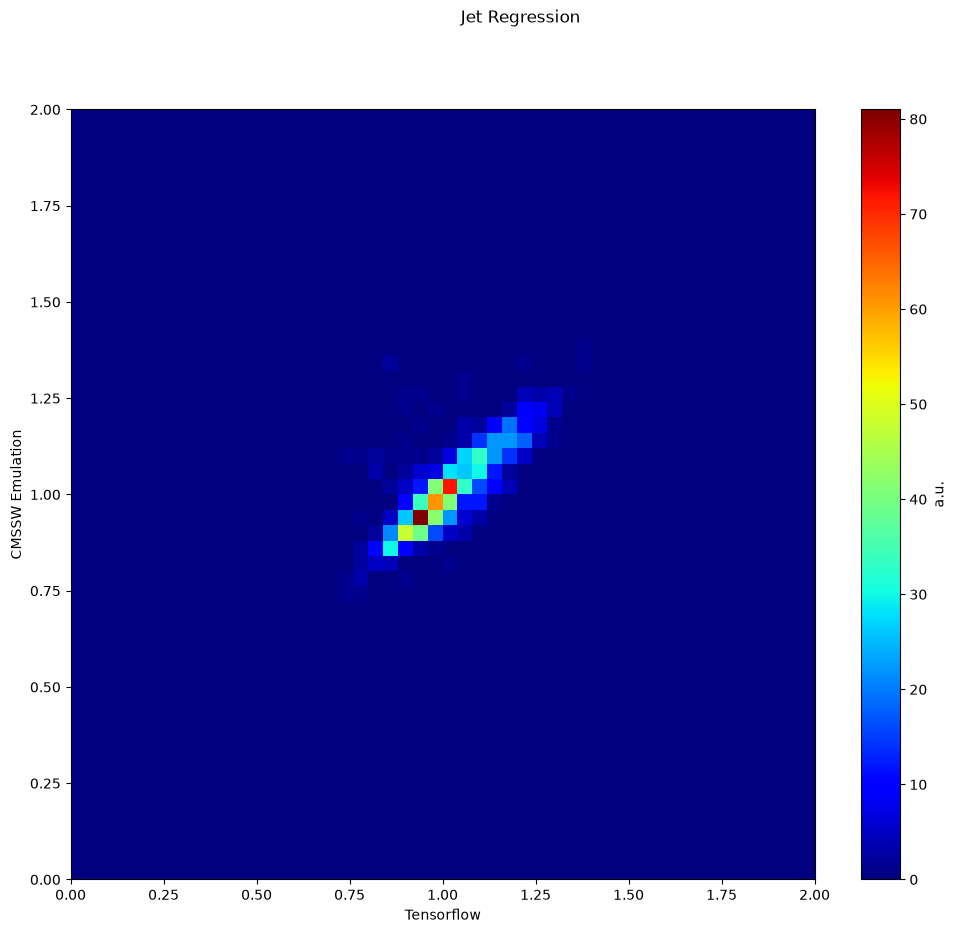

In [29]:
# Regression plots
figure = plot_2d(
    y_ptreg[:, 0],
    # cmssw_scores['jet_SC4NGJet_score_regression'],
    y_ptreg_hls[:, 0],
    (0, 2), (0, 2),
    "Tensorflow", "CMSSW Emulation", "Jet Regression"
)


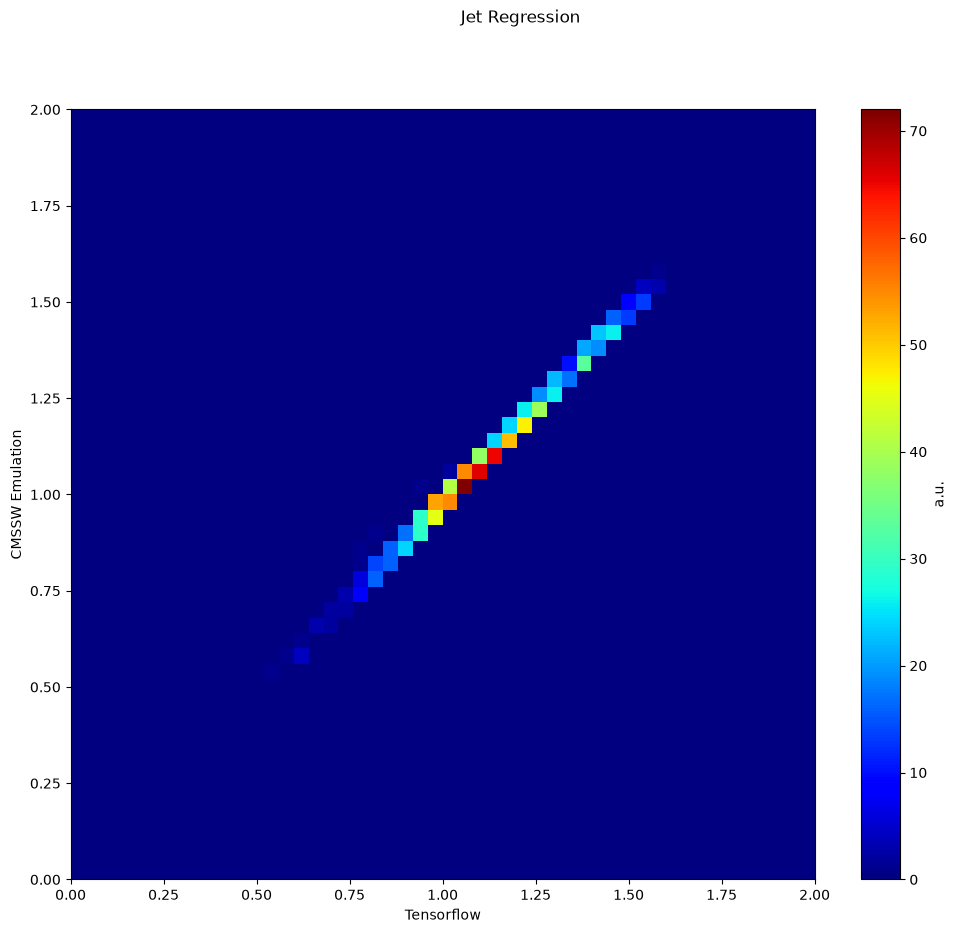

In [25]:
# Regression plots baseline
figure = plot_2d(
    y_ptreg_baseline[:, 0],
    y_ptreg_hls_baseline[:, 0],
    (0, 2), (0, 2),
    "Tensorflow", "CMSSW Emulation", "Jet Regression"
)

<Figure size 640x480 with 0 Axes>

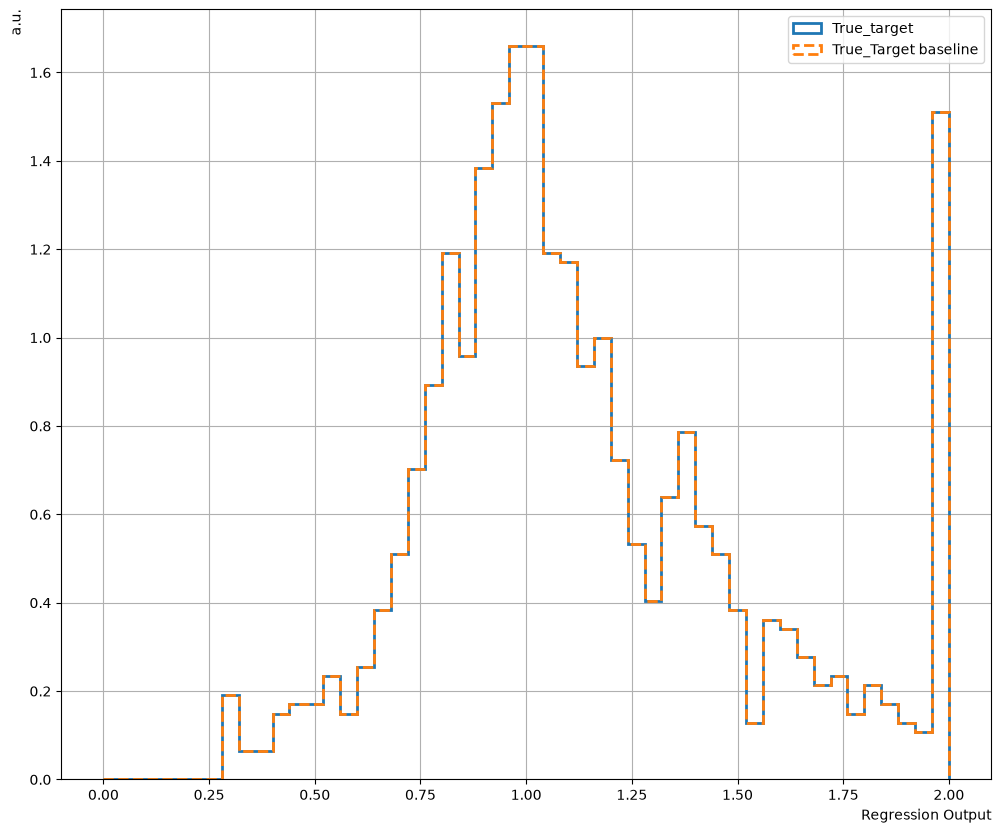

In [46]:
figure = plot_histo(
    [pt_train,
     pt_target],
    ["True_target", "True_Target baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)

Bit accuracy (regression): 0.51%


<Figure size 640x480 with 0 Axes>

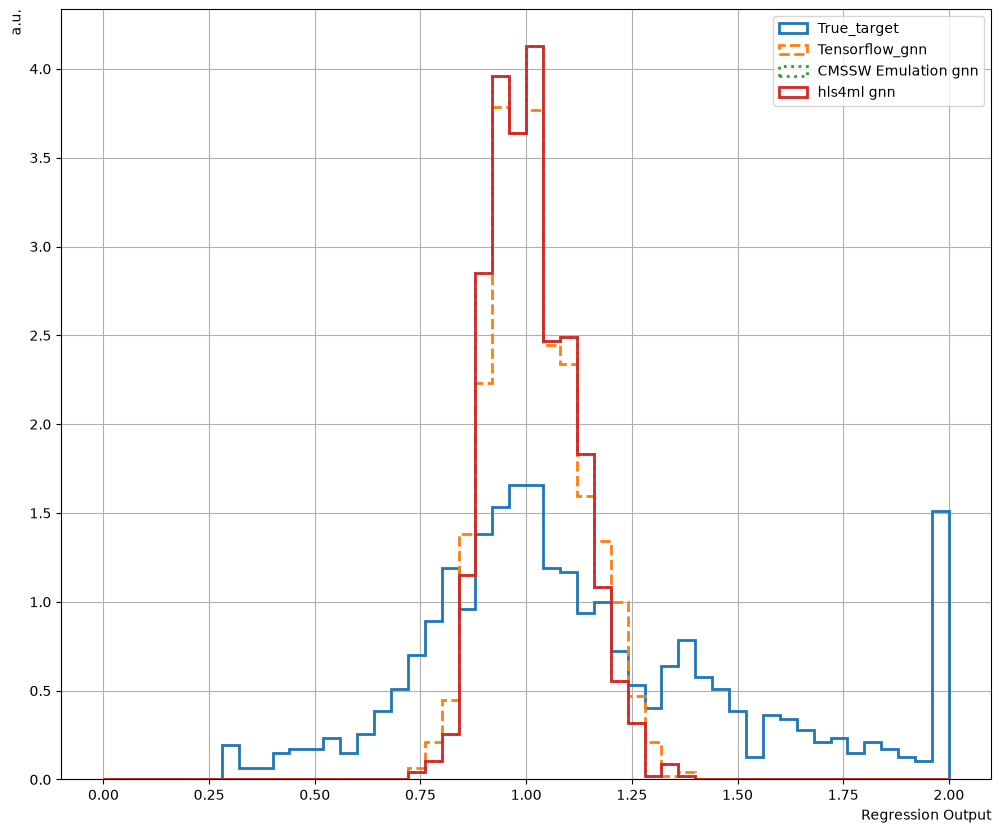

In [52]:
figure = plot_histo(
    [pt_train,                                       # Ground truth target
     y_ptreg[:, 0],
     cmssw_scores['jet_SC4NGJet_score_regression'],
     y_ptreg_hls[:, 0]],
    ["True_target","Tensorflow_gnn", "CMSSW Emulation gnn", 
     "hls4ml gnn"], #"Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)

bit_accurate = np.count_nonzero(
    cmssw_scores['jet_SC4NGJet_score_regression'] - y_ptreg_hls[:, 0]
)
print(f"Bit accuracy (regression): {100 - 100*bit_accurate/len(X_train):.2f}%")

Bit accuracy (regression): 0.51%


<Figure size 640x480 with 0 Axes>

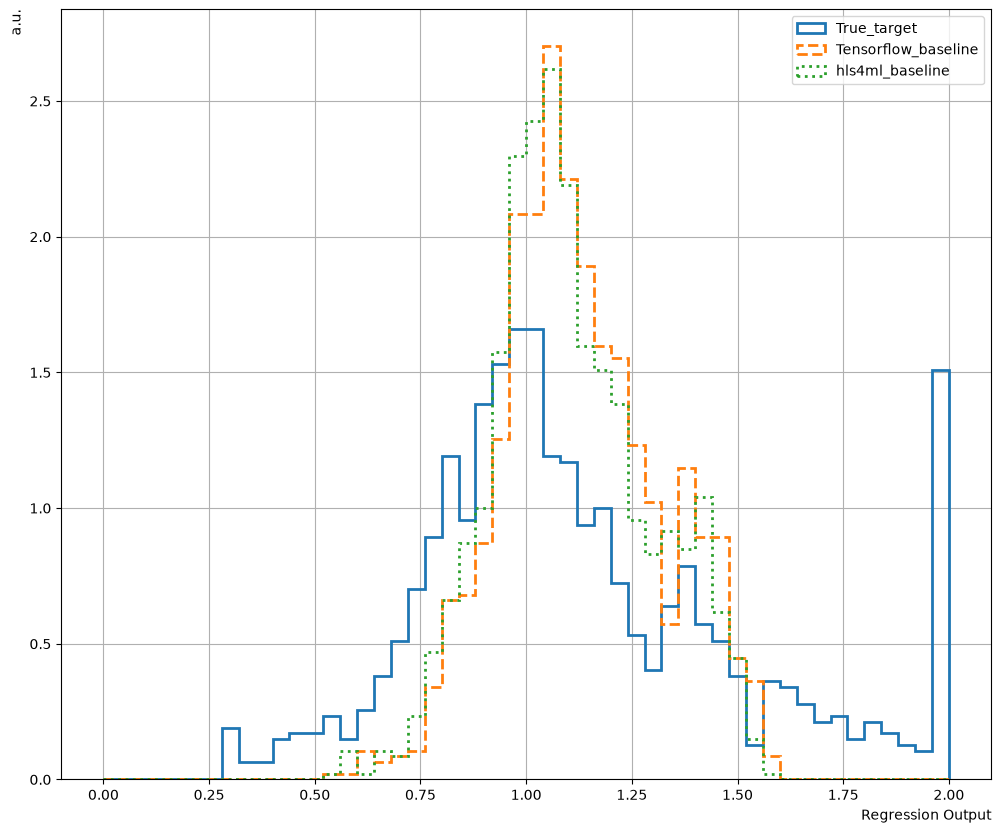

In [53]:
figure = plot_histo(
    [pt_train,                                       # Ground truth target
    #  y_ptreg[:, 0],
    # #  cmssw_scores['jet_SC4NGJet_score_regression'],
    #  y_ptreg_hls[:, 0],
     y_ptreg_baseline[:, 0],
     y_ptreg_hls_baseline[:, 0]],
    ["True_target","Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)

bit_accurate = np.count_nonzero(
    cmssw_scores['jet_SC4NGJet_score_regression'] - y_ptreg_hls[:, 0]
)
print(f"Bit accuracy (regression): {100 - 100*bit_accurate/len(X_train):.2f}%")

Bit accuracy (regression): 0.51%


<Figure size 640x480 with 0 Axes>

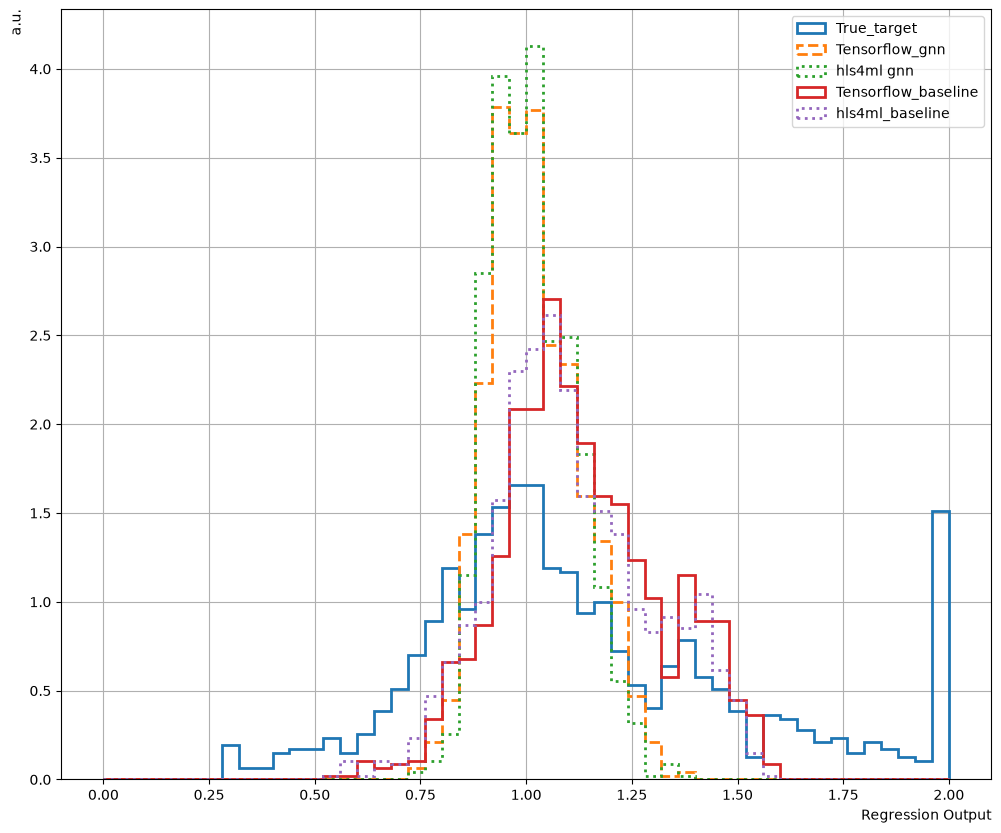

In [54]:
figure = plot_histo(
    [pt_train,                                       # Ground truth target
     y_ptreg[:, 0],
    #  cmssw_scores['jet_SC4NGJet_score_regression'],
     y_ptreg_hls[:, 0],
     y_ptreg_baseline[:, 0],
     y_ptreg_hls_baseline[:, 0]],
    ["True_target","Tensorflow_gnn", # "CMSSW Emulation gnn", 
     "hls4ml gnn", "Tensorflow_baseline", "hls4ml_baseline"],
    "", 'Regression Output', 'a.u.', range=(0, 2)
)

bit_accurate = np.count_nonzero(
    cmssw_scores['jet_SC4NGJet_score_regression'] - y_ptreg_hls[:, 0]
)
print(f"Bit accuracy (regression): {100 - 100*bit_accurate/len(X_train):.2f}%")

In [49]:
import numpy as np

# --- Normalize ground truth labels to integer class indices ---
def to_int_labels(y):
    y = np.asarray(y)
    if y.ndim == 2:          # one-hot or probability-like
        return np.argmax(y, axis=1)
    return y.astype(int)     # already integer labels
y_train = tf.keras.utils.to_categorical(y_train_raw, num_classes=len(class_labels)).astype(np.float32)
y_true_gnn      = to_int_labels(y_train)   # GNN ground truth (train set, since test_ratio=0.0)
y_true_baseline = to_int_labels(Y_test)        # baseline ground truth

# --- Model class predictions (argmax over class probabilities) ---
preds = {
    "Tensorflow_gnn":      np.argmax(y_class, axis=1),
    "CMSSW Emulation gnn": None,  # filled in below if you have classification scores from CMSSW
    "hls4ml gnn":          np.argmax(y_hls, axis=1),
    "Tensorflow_baseline": np.argmax(y_class_baseline, axis=1),
    "hls4ml_baseline":     np.argmax(y_hls_baseline, axis=1),
}

# If you also pulled classification scores from CMSSW root file, build the same way as regression:
class_score_keys = [
    'jet_SC4NGJet_score_b', 'jet_SC4NGJet_score_charm', 'jet_SC4NGJet_score_light',
    'jet_SC4NGJet_score_gluon', 'jet_SC4NGJet_score_taup', 'jet_SC4NGJet_score_taum',
    'jet_SC4NGJet_score_muon', 'jet_SC4NGJet_score_electron'
]
if all(k in cmssw_scores for k in class_score_keys):
    cmssw_class_probs = np.stack([cmssw_scores[k] for k in class_score_keys], axis=1)
    preds["CMSSW Emulation gnn"] = np.argmax(cmssw_class_probs, axis=1)
else:
    del preds["CMSSW Emulation gnn"]
    print("CMSSW classification scores not found in cmssw_scores — skipping that model for class accuracy.")

# --- Map each model to the correct ground-truth array ---
truth_for_model = {
    "Tensorflow_gnn":      y_true_gnn,
    "CMSSW Emulation gnn": y_true_gnn,
    "hls4ml gnn":          y_true_gnn,
    "Tensorflow_baseline": y_true_baseline,
    "hls4ml_baseline":     y_true_baseline,
}

# --- Per-class accuracy (recall) loop ---
results = {}  # results[class_name][model_name] = accuracy

for class_name, class_idx in class_labels.items():
    results[class_name] = {}
    for model_name, y_pred in preds.items():
        y_true = truth_for_model[model_name]
        mask = (y_true == class_idx)
        n = mask.sum()
        if n == 0:
            results[class_name][model_name] = np.nan
            continue
        correct = np.sum(y_pred[mask] == class_idx)
        results[class_name][model_name] = 100.0 * correct / n

# --- Pretty print ---
model_names = list(preds.keys())
header = f"{'Class':<12}" + "".join(f"{m:>22}" for m in model_names)
print(header)
print("-" * len(header))
for class_name in class_labels.keys():
    row = f"{class_name:<12}"
    for model_name in model_names:
        val = results[class_name][model_name]
        row += f"{val:>21.2f}%" if not np.isnan(val) else f"{'N/A':>22}"
    print(row)

Class               Tensorflow_gnn   CMSSW Emulation gnn            hls4ml gnn   Tensorflow_baseline       hls4ml_baseline
--------------------------------------------------------------------------------------------------------------------------
b                            8.39%                 3.01%                 5.38%                 3.23%                 3.87%
charm                        0.00%                 0.00%                 0.00%                18.18%                18.18%
light                       28.57%                26.98%                26.98%                55.56%                52.38%
gluon                        7.11%                 0.51%                 0.00%                10.15%                 3.55%
taup                        62.41%                26.24%                65.25%                52.48%                56.03%
taum                        49.39%                25.00%                48.17%                 2.44%                 1.83%
muon            

In [50]:
print("class_labels dict:", class_labels)
print("y_train_raw sample:", y_train_raw[:20], y_train_raw.shape, y_train_raw.dtype)
print("Y_test sample:", Y_test[:5], Y_test.shape, Y_test.dtype)

# class balance check — this is the key diagnostic
import numpy as np
print("GNN truth distribution:", np.bincount(to_int_labels(y_train_raw)))
print("Baseline truth distribution:", np.bincount(to_int_labels(Y_test)))

# argmax distribution of predictions
print("Tensorflow_gnn pred distribution:", np.bincount(np.argmax(y_class, axis=1), minlength=8))
print("Tensorflow_baseline pred distribution:", np.bincount(np.argmax(y_class_baseline, axis=1), minlength=8))

class_labels dict: {'b': 0, 'charm': 1, 'light': 2, 'gluon': 3, 'taup': 4, 'taum': 5, 'muon': 6, 'electron': 7}
y_train_raw sample: [4 0 0 4 0 0 5 4 5 0 7 3 0 5 0 0 0 5 0 0] (1175,) int64
Y_test sample: [[0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]] (1175, 8) float32
GNN truth distribution: [465  22  63 197 141 164  62  61]
Baseline truth distribution: [465  22  63 197 141 164  62  61]
Tensorflow_gnn pred distribution: [ 49   6 292  29 255 283  52 209]
Tensorflow_baseline pred distribution: [ 30  93 602  66 248  11  24 101]


Bit accuracy (b): 0.60%
Bit accuracy (charm): 0.43%
Bit accuracy (light): 0.51%
Bit accuracy (gluon): 0.68%
Bit accuracy (taup): 0.51%
Bit accuracy (taum): 0.68%
Bit accuracy (muon): 3.91%
Bit accuracy (electron): 0.43%


<Figure size 640x480 with 0 Axes>

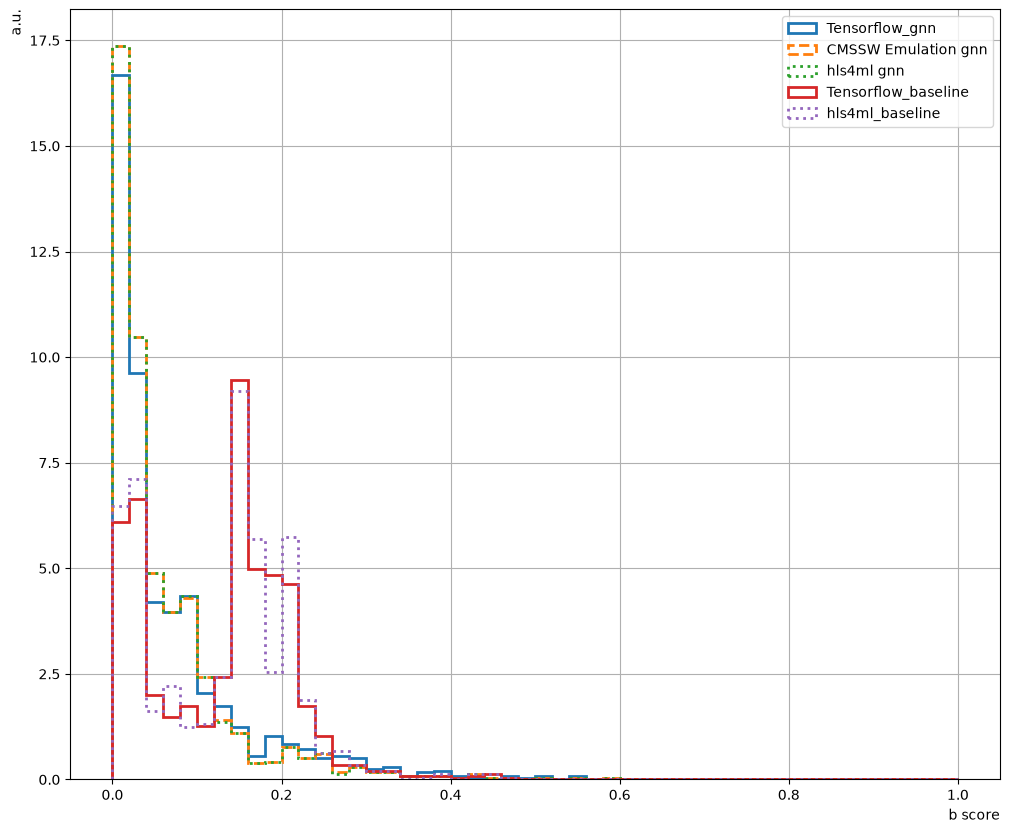

<Figure size 1200x1000 with 0 Axes>

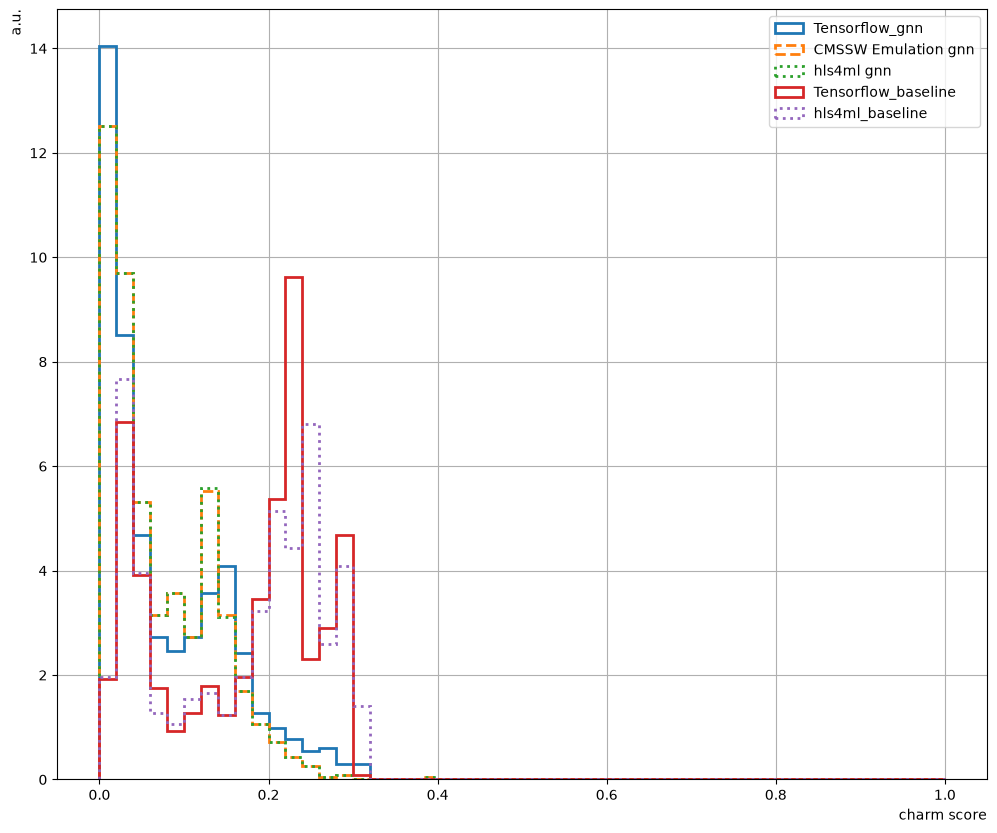

<Figure size 1200x1000 with 0 Axes>

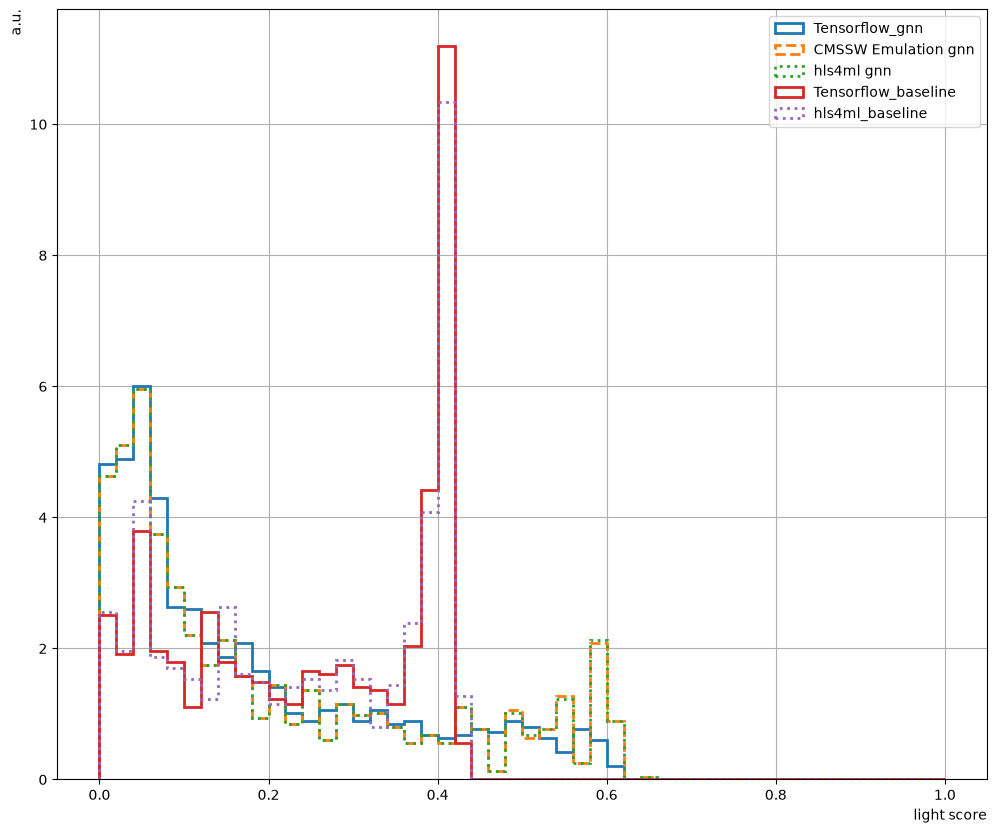

<Figure size 1200x1000 with 0 Axes>

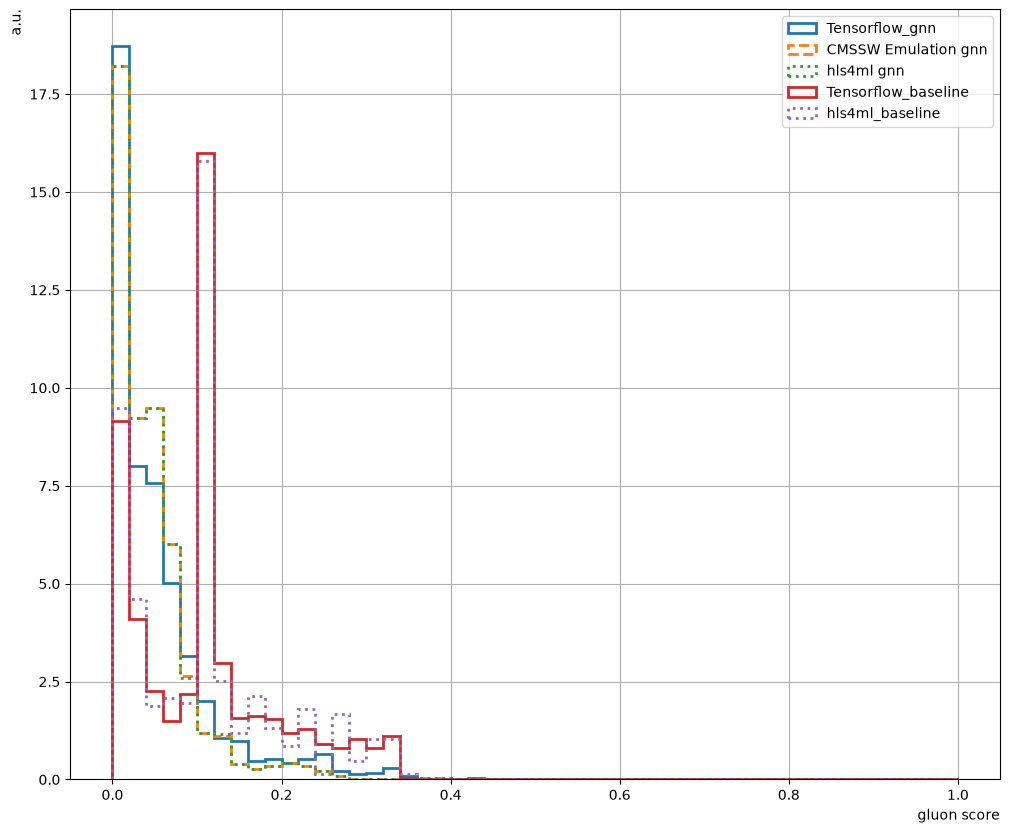

<Figure size 1200x1000 with 0 Axes>

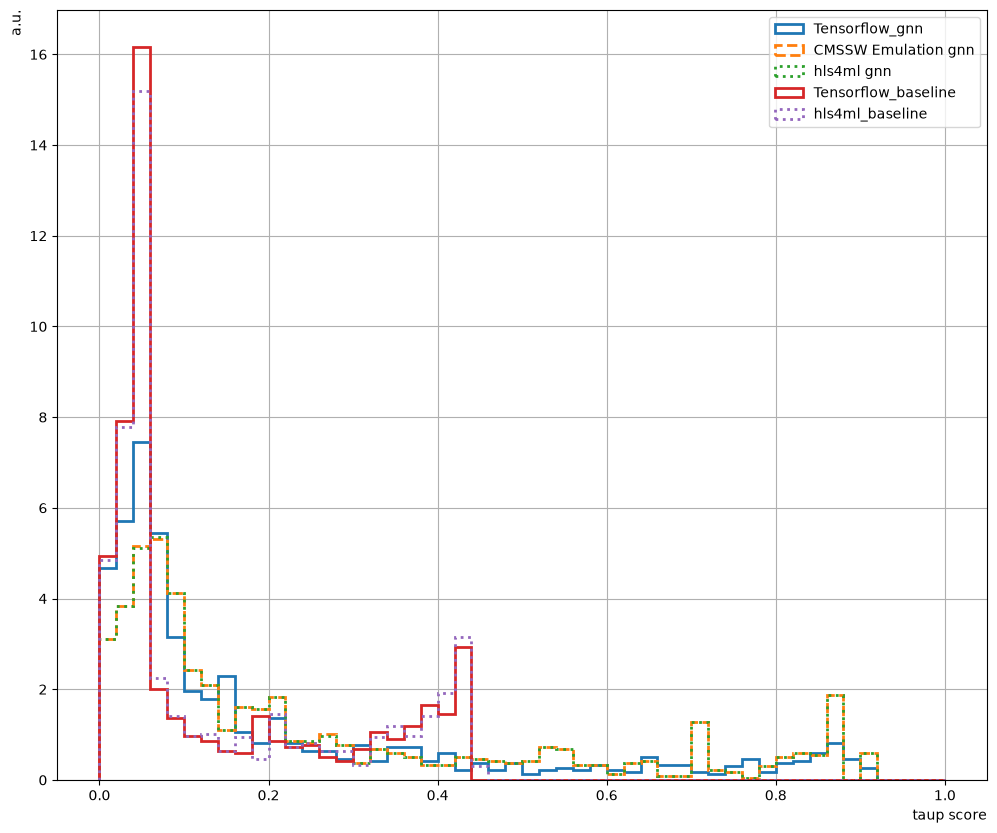

<Figure size 1200x1000 with 0 Axes>

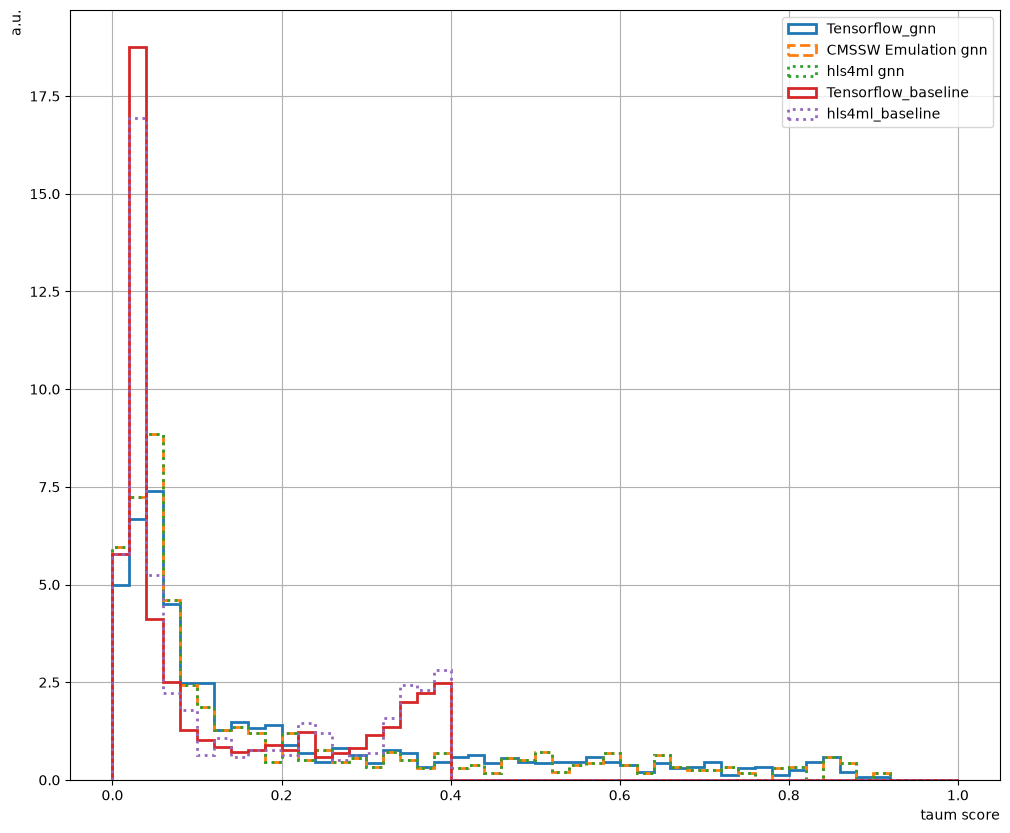

<Figure size 1200x1000 with 0 Axes>

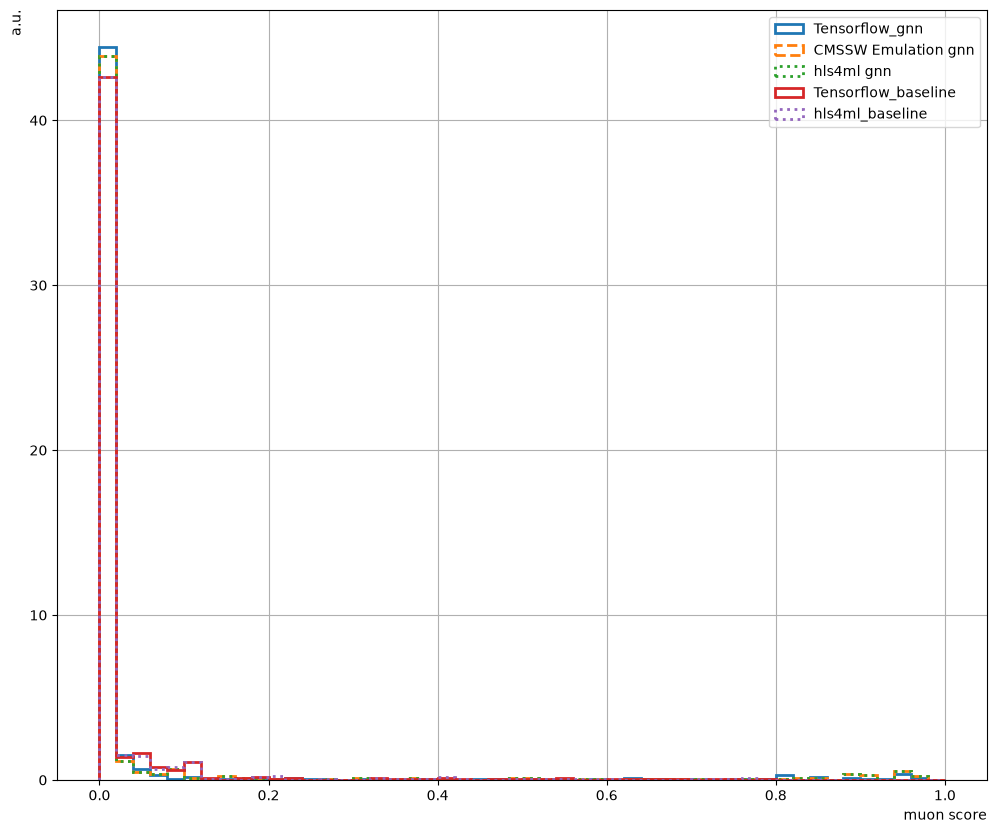

<Figure size 1200x1000 with 0 Axes>

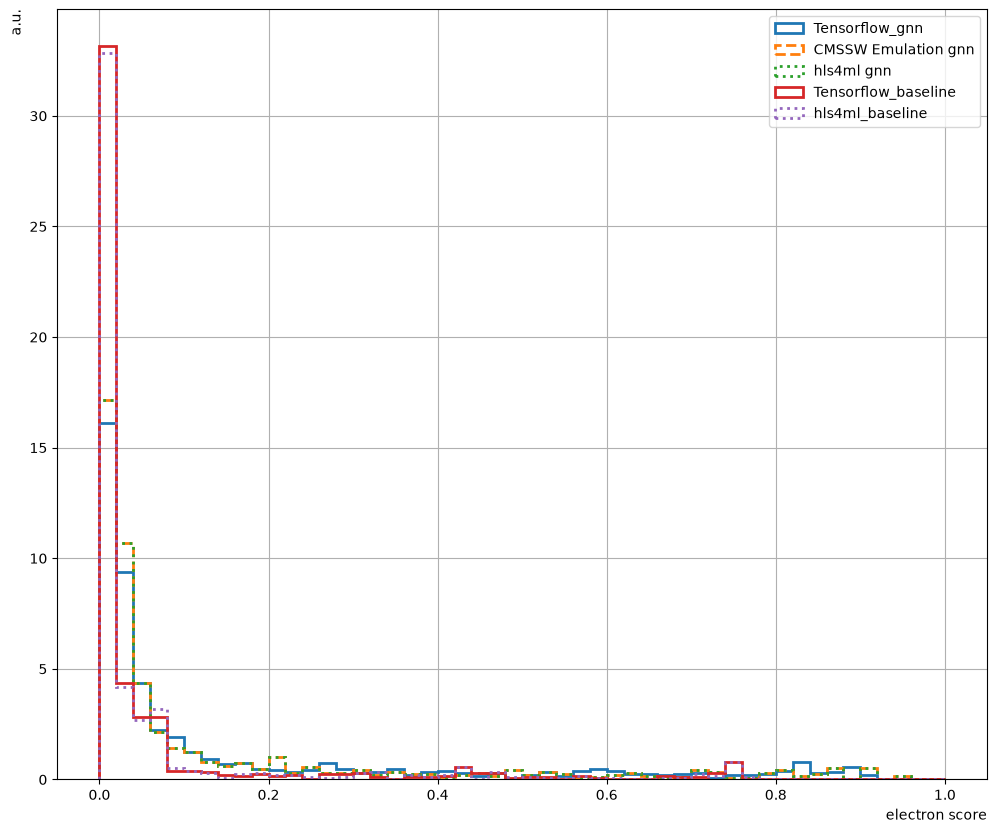

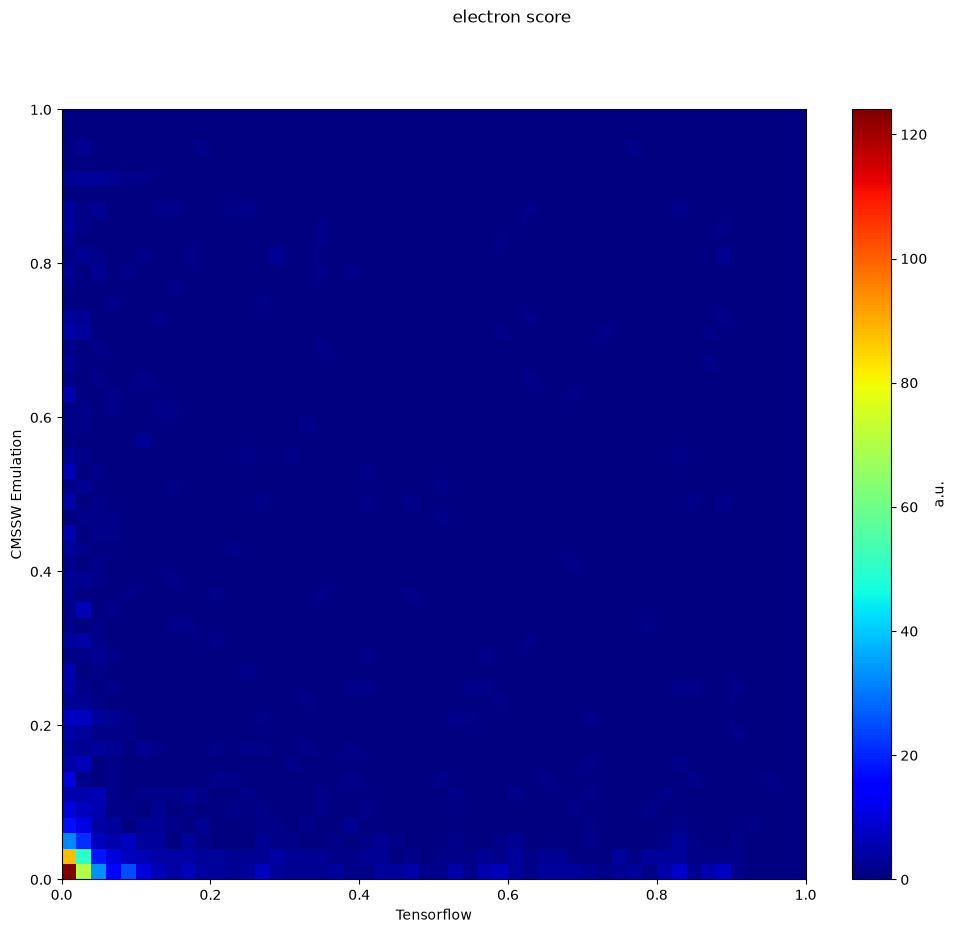

In [36]:
# Classification plots — loop over all labels
cmssw_key_map = {
    'b':     'jet_SC4NGJet_score_b',
    'c':     'jet_SC4NGJet_score_charm',
    'uds':   'jet_SC4NGJet_score_light',
    'g':     'jet_SC4NGJet_score_gluon',
    'tau_p': 'jet_SC4NGJet_score_taup',
    'tau_n': 'jet_SC4NGJet_score_taum',
    'mu':    'jet_SC4NGJet_score_muon',
    'e':     'jet_SC4NGJet_score_electron',
}

for i, label in enumerate(labels):
    cmssw_key = cmssw_key_map.get(label, f'jet_SC4NGJet_score_{label}')
    cmssw_label = cmssw_scores[cmssw_key]

    figure = plot_histo(
        [y_class[:, i],cmssw_label,y_hls[:, i],y_class_baseline[:, i],y_hls_baseline[:, i]],
        ["Tensorflow_gnn", "CMSSW Emulation gnn", "hls4ml gnn", "Tensorflow_baseline", "hls4ml_baseline"],
        # [y_class[:, i], cmssw_label, y_hls[:, i]],
        # ["Tensorflow", "CMSSW Emulation", "hls4ml"],
        "", f'{label} score', 'a.u.', range=(0, 1))
    # figure.savefig(f'plot_histo_{label}.png')

    figure = plot_2d(
        y_class[:, i], cmssw_label,
        (0, 1), (0, 1),
        "Tensorflow", "CMSSW Emulation", f"{label} score"
    )
    # figure.savefig(f'plot_2d_{label}.png')

    bit_accurate = np.count_nonzero(cmssw_label - y_hls[:, i])
    print(f"Bit accuracy ({label}): {100 - 100*bit_accurate/len(X_train):.2f}%")

# Plot results

Now we plot some histograms of emulator vs tensorflow vs hls4ml

In [ ]:


figure = plot_2d(np.array(y_ptreg[:,0]) ,np.array(X_train['jet_SC4NGJet_score_regression']) ,(0,2),(0,2),"Tensorflow","CMSSW Emulation","Jet Regression")


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:

figure = plot_histo([y_ptreg[:,0],np.array(X_train['jet_SC4NGJet_score_regression']),np.array(y_ptreg_hls[:,0])],["Tensorflow","CMSSW Emulation", "hls4ml"],"",'Regression Output','a.u.',range=(0,2))

In [ ]:

bit_accurate = np.count_nonzero((np.array(data['jet_SC4NGJet_score_regression']) - np.array(y_ptreg_hls[:,0])))
print("Percent bit accuracy between CMSSW emulator and hls4ml for regression is",100 - 100*bit_accurate/len(np.array(data['jet_SC4NGJet_score_regression'])), "%")


In [ ]:

i,label = 0,labels[0]
figure = plot_histo([np.array(y_class[:,i]),np.array(data['jet_SC4NGJet_score_'+label]),np.array(y_hls[:,i])],["Tensorflow","CMSSW Emulation", "hls4ml"],"",label+' score','a.u.',range=(0,1))
bit_accurate = np.count_nonzero((np.array(data['jet_SC4NGJet_score_'+label]) - np.array(y_hls[:,i])))
print("Percent bit accuracy between CMSSW emulator and hls4ml for " + label + " classification is",  100 - 100*bit_accurate/len(np.array(data['jet_SC4NGJet_score_'+label])), "%")

In [ ]:
i,label = 0,labels[0]
figure = plot_2d(np.array(y_class[:,i]),np.array(data['jet_SC4NGJet_score_'+label]),(0,1),(0,1),"Tensorflow","CMSSW Emulation",label+" score")
